In [2]:
import numpy as np 
import pylab as plt 
import networkx as nx

In [2]:
X = np.load("rat_umap.npy")
data = np.load("grid_cells_4800.npz")

In [3]:
spikes = data['spikes']

In [6]:
X += 0.5 
X %= 1.0

Text(0.5, 0.98, 'Embedding of grid cells colored by firing rate of Cell 39')

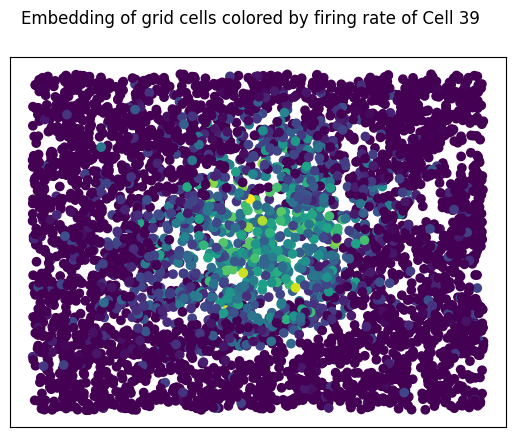

In [8]:
plt.scatter(X[:,0],X[:,1], c=spikes[:,39])

plt.xticks([])
plt.yticks([])
plt.suptitle("Embedding of grid cells colored by firing rate of Cell 39")

Text(0.5, 0.98, 'Firing rates of selected cells by spatial position\n Toroidal embedding')

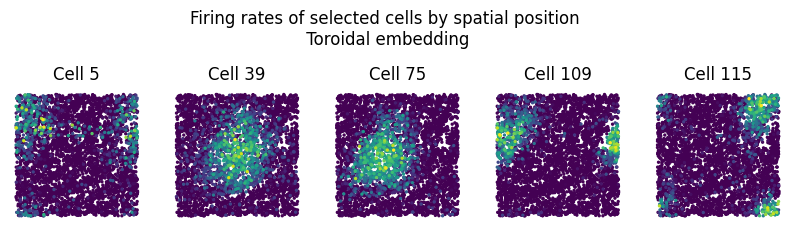

In [10]:
# spatial location of firing rates
fig, ax = plt.subplots(1, 5, figsize=(10, 3))

cell_ids = [5, 39, 75, 109, 115] # cells with clearly structured firing pattern

xx = X[:,0]
yy = X[:,1]
for i, idx in enumerate(cell_ids):
    order  = np.argsort(spikes[:, idx])  # to plot interesting time points on top
    ax[i].scatter(xx[order], yy[order], c=spikes[order, idx], s=2)
    ax[i].set_title(f"Cell {idx}")
    ax[i].axis("off")
    ax[i].set_aspect("equal")
fig.suptitle("Firing rates of selected cells by spatial position\n Toroidal embedding")

In [3]:
def torus_delta(p, q):
    """Shortest displacement from p to q on unit square torus (per-coordinate in [-0.5, 0.5))."""
    return ((q - p + 0.5) % 1.0) - 0.5

def torus_edge_segments(p, q, eps=1e-12):
    """
    Return list of (a_plot, b_plot) segments to draw the shortest torus geodesic between p and q,
    plotted in the fundamental domain [0,1]x[0,1], split at boundary crossings.

    p, q are assumed to be in [0,1)^2.
    """
    p = np.asarray(p, dtype=np.float64)
    q = np.asarray(q, dtype=np.float64)

    d = torus_delta(p, q)
    r = p + d  # endpoint in covering space (may lie outside [0,1) )

    ts = [0.0, 1.0]

    # boundary crossings for each coordinate
    for k in (0, 1):
        dk = d[k]
        if abs(dk) < eps:
            continue

        # Determine which boundary is crossed (if any) based on direction and endpoint r
        if dk > 0 and r[k] > 1.0 + eps:
            b = 1.0
        elif dk < 0 and r[k] < 0.0 - eps:
            b = 0.0
        else:
            continue

        t = (b - p[k]) / dk
        if eps < t < 1.0 - eps:
            ts.append(float(t))

    ts = sorted(set(ts))

    segs = []
    for t0, t1 in zip(ts[:-1], ts[1:]):
        a = p + t0 * d
        b = p + t1 * d

        # Choose a single tile shift so BOTH endpoints land in the same plotted tile.
        mid = 0.5 * (a + b)
        tile = np.floor(mid)  # integer vector, typically in {-1,0,1}^2 here

        a_plot = a - tile
        b_plot = b - tile

        # Numerical guard: keep within [0,1] for plotting
        a_plot = np.clip(a_plot, 0.0, 1.0)
        b_plot = np.clip(b_plot, 0.0, 1.0)

        segs.append((a_plot, b_plot))

    return segs

def plot_embedding_with_torus_edges(X, G, outpath="output.png",
                                   s=10, node_alpha=0.9,
                                   edge_alpha=0.10, edge_lw=0.4, 
                                   ax=None):
    """
    Scatter + edges drawn along shortest torus paths in [0,1)^2.

    X: (N,2) embedding (can be unwrapped; we'll wrap for plotting)
    nodes: list of nodes matching row order of X
    G: networkx graph
    """
    X = np.asarray(X, dtype=np.float64) % 1.0
    idx = {n: i for i, n in enumerate(G.nodes())}

    if ax == None: 
        fig, ax = plt.subplots()
    

    # edges
    for u, v in G.edges():
        i, j = idx[u], idx[v]
        p, q = X[i], X[j]
        for a, b in torus_edge_segments(p, q):
            ax.plot([a[0], b[0]], [a[1], b[1]],
                     color="k", alpha=edge_alpha, lw=edge_lw, zorder=1)

    # points
    ax.scatter(X[:, 0], X[:, 1], s=s, alpha=node_alpha, zorder=2)

    ax.set_xlim(0, 1)
    ax.set_ylim(0, 1)
    # plt.gca().set_aspect("equal", adjustable="box")
    plt.tight_layout()
    # plt.savefig(outpath, dpi=200)
    # plt.close()
    return ax

In [4]:
def apsp_distance_matrix(G: nx.Graph, weight: str = "weight") -> tuple[np.ndarray, list]:
    """
    Compute all-pairs shortest path (APSP) distance matrix using NetworkX.

    Returns:
    D: (N,N) float64 distance matrix
    nodes: list of nodes in the order used for D
    """
    nodes = list(G.nodes())
    idx = {n: k for k, n in enumerate(nodes)}
    n = len(nodes)
    D = np.zeros((n, n), dtype=np.float64)

    # all_pairs_dijkstra_path_length works for unit weights too
    for src, dist_dict in nx.all_pairs_dijkstra_path_length(G, weight=weight):
        i = idx[src]
        for dst, d in dist_dict.items():
            D[i, idx[dst]] = float(d)

    return D, nodes

In [ ]:
G = nx.planted_partition_graph(5, 100, 0.2, 0.01)
d, nodes = apsp_distance_matrix(G)

In [7]:
from projector import MDSTorusProjector
X_torus = MDSTorusProjector().fit_transform(d)

/home/jacob253/Desktop/torus/projector.py:47: SyntaxWarning: invalid escape sequence '\s'
  """Standard euclidean distance and its gradient.


ValueError: setting an array element with a sequence. The requested array has an inhomogeneous shape after 2 dimensions. The detected shape was (2, 500) + inhomogeneous part.